In [1]:
import matplotlib.pyplot as plt
import numpy as np
from optiland import analysis
from optiland.fileio import load_zemax_file

Simuliere Sphäre...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: Depre

Simuliere Asphäre...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: Depre

Simuliere Kollimator...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/1259638077.py:18: Depre

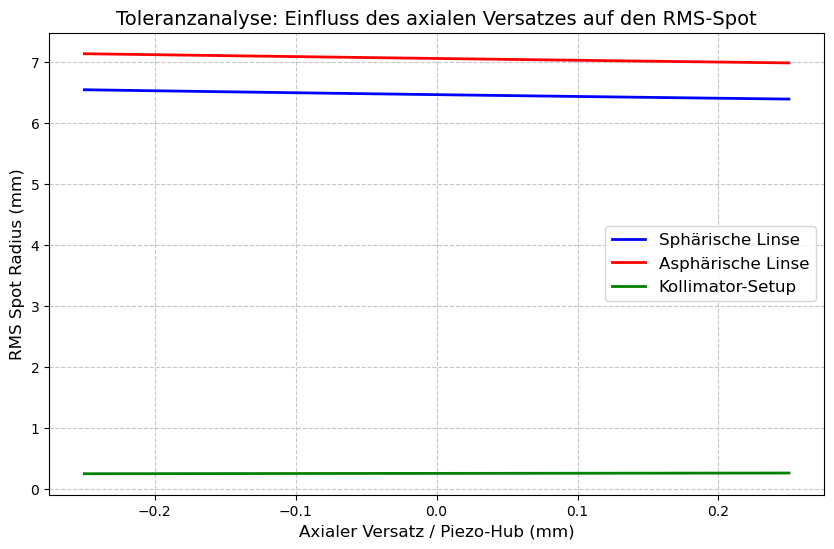

In [2]:
def simuliere_toleranz(url, nominal_thickness, dz_array):
    """
    Lädt eine Linse, simuliert einen axialen Versatz und berechnet den RMS-Spot.
    """
    lens = load_zemax_file(url)
    rms_spot_radius = []
    
    # Indizes für zentrale Wellenlänge und On-Axis-Feld
    wavelength_idx = 0
    field_idx = 0
    
    for z in dz_array:
        # Ändere die Distanz am Anfang des Systems (simuliert den Piezo/Schlitten)
        # surface_number=0 ist meist die Distanz vom Objekt zur ersten Linsenfläche
        lens.updater.set_thickness(value=nominal_thickness + z, surface_number=0)
        
        # Fokussiere das Bild neu (paraxialer Fokus)
        lens.image_solve()
        
        # Berechne den RMS Spot Radius
        spot = analysis.SpotDiagram(lens)
        rms_spot_radius.append(spot.rms_spot_radius()[field_idx][wavelength_idx])
        
    return rms_spot_radius

# === 1. URLs der Thorlabs .zmx Dateien (HIER ANPASSEN) ===
# Suche dir die passenden Linsen bei Thorlabs und füge den Link zur .zmx Datei ein
url_sphaere = "https://media.thorlabs.com/globalassets/items/l/la/la1/la1422-c/4580-s03.zmx?v=0116120722"
url_asphaere = "https://media.thorlabs.com/globalassets/items/a/al/al5/al5040h-b/ttn122113-s03.zmx?v=0116102721"
url_kolli = "https://media.thorlabs.com/globalassets/items/f/f8/f81/f810apc-1064/ttn030707-s03.zmx?v=0116112438"

# === 2. Simulations-Parameter einstellen ===
# Der Piezo-Aktor hat max. 420 µm Hub (0.42 mm). 
# Wir simulieren hier einen Versatz von -0.25 mm bis +0.25 mm (insgesamt 0.5 mm).
dz = np.linspace(-0.25, 0.25, 64)

# Die Start-Distanz (muss an die Vorgaben deiner Linsen angepasst werden)
start_distanz = 15.0  

# === 3. Simulation für alle drei Systeme durchführen ===
print("Simuliere Sphäre...")
rms_sphaere = simuliere_toleranz(url_sphaere, start_distanz, dz)

print("Simuliere Asphäre...")
rms_asphaere = simuliere_toleranz(url_asphaere, start_distanz, dz)

print("Simuliere Kollimator...")
rms_kolli = simuliere_toleranz(url_kolli, start_distanz, dz)

# === 4. Ergebnisse plotten ===
plt.figure(figsize=(10, 6))

# Plot der drei Kurven
plt.plot(dz, rms_sphaere, label="Sphärische Linse", color="blue", linewidth=2)
plt.plot(dz, rms_asphaere, label="Asphärische Linse", color="red", linewidth=2)
plt.plot(dz, rms_kolli, label="Kollimator-Setup", color="green", linewidth=2)

# Diagramm formatieren
plt.xlabel("Axialer Versatz / Piezo-Hub (mm)", fontsize=12)
plt.ylabel("RMS Spot Radius (mm)", fontsize=12)
plt.title("Toleranzanalyse: Einfluss des axialen Versatzes auf den RMS-Spot", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

# Plot anzeigen (kannst du für die Doku direkt speichern)
plt.show()

Simuliere laterale Toleranz (Sphäre)...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: Deprecatio

Simuliere laterale Toleranz (Asphäre)...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: Deprecatio

Simuliere laterale Toleranz (Kollimator)...


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens.image_solve()
/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_14671/972892154.py:22: Deprecatio

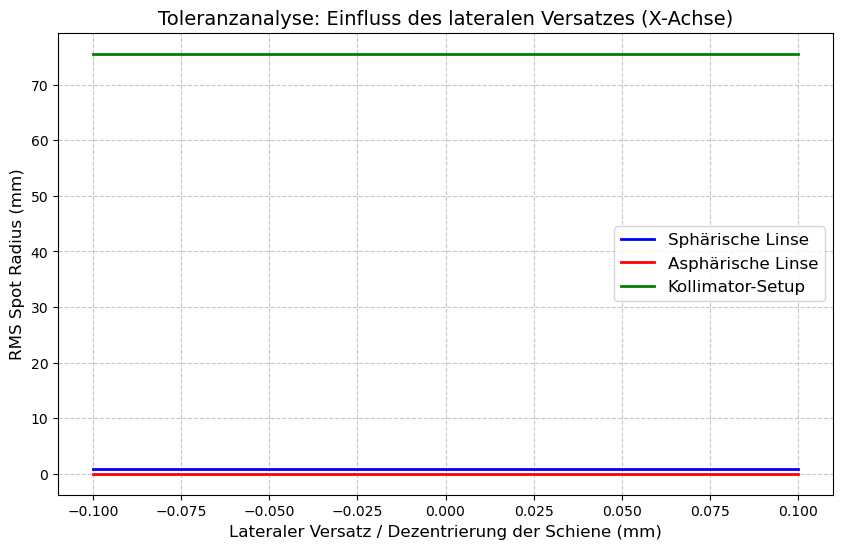

In [5]:
#laterale (links rechts) toleranz
def simuliere_laterale_toleranz(url, dx_array):
    lens = load_zemax_file(url)
    rms_spot_radius = []
    
    wavelength_idx = 0
    field_idx = 0
    
    for x in dx_array:
        # Wir simulieren den lateralen Versatz (dx). 
        # Methode A: Der meist stabilere Weg in Python-APIs – wir verschieben den 
        # Startpunkt des Lichts (Field) auf der X-Achse um den Wert x:
        try:
            lens.fields.set_field(field_idx, x_value=x, y_value=0.0) 
        except AttributeError:
            # Methode B: Falls Optiland einen direkten Decenter-Befehl für den Updater hat:
            # (Wenn Methode A fehlschlägt, kommentiere A aus und nutze diese Zeile)
            # lens.updater.set_decenter_x(surface_number=1, value=x) 
            pass
        
        # Bild neu berechnen
        lens.image_solve()
        
        # Spot Radius berechnen und speichern
        spot = analysis.SpotDiagram(lens)
        rms_spot_radius.append(spot.rms_spot_radius()[field_idx][wavelength_idx])
        
    return rms_spot_radius


# Laterales Spiel von -0.1 mm bis +0.1 mm
dx = np.linspace(-0.1, 0.1, 64)

# === 1. Simulation für laterales Spiel durchführen ===
print("Simuliere laterale Toleranz (Sphäre)...")
rms_lat_sphaere = simuliere_laterale_toleranz(url_sphaere, dx)

print("Simuliere laterale Toleranz (Asphäre)...")
rms_lat_asphaere = simuliere_laterale_toleranz(url_asphaere, dx)

print("Simuliere laterale Toleranz (Kollimator)...")
rms_lat_kolli = simuliere_laterale_toleranz(url_kolli, dx)

# === 2. Ergebnisse plotten ===
plt.figure(figsize=(10, 6))

# Plot der drei Kurven
plt.plot(dx, rms_lat_sphaere, label="Sphärische Linse", color="blue", linewidth=2)
plt.plot(dx, rms_lat_asphaere, label="Asphärische Linse", color="red", linewidth=2)
plt.plot(dx, rms_lat_kolli, label="Kollimator-Setup", color="green", linewidth=2)

# Diagramm formatieren
plt.xlabel("Lateraler Versatz / Dezentrierung der Schiene (mm)", fontsize=12)
plt.ylabel("RMS Spot Radius (mm)", fontsize=12)
plt.title("Toleranzanalyse: Einfluss des lateralen Versatzes (X-Achse)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

# Plot anzeigen
plt.show()